# 🧁 Muffin vs Cupcake — ML Classification Notebook
**Dataset:** `recipes_muffins_cupcakes.csv`  
**Task:** Binary Classification (Muffin or Cupcake)  
**Model:** SVM  
**Author:** Ishfaque Ahmed | BS Mathematics, Sukkur IBA University

---

## 1. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print('Libraries imported!')

Libraries imported!


## 2. Load Dataset

In [17]:
df = pd.read_csv('/content/recipes_muffins_cupcakes.csv')

print('Shape:', df.shape)
print(df)

Shape: (20, 9)
       Type  Flour  Milk  Sugar  Butter  Egg  Baking Powder  Vanilla  Salt
0    Muffin     55    28      3       7    5              2        0     0
1    Muffin     47    24     12       6    9              1        0     0
2    Muffin     47    23     18       6    4              1        0     0
3    Muffin     45    11     17      17    8              1        0     0
4    Muffin     50    25     12       6    5              2        1     0
5    Muffin     55    27      3       7    5              2        1     0
6    Muffin     54    27      7       5    5              2        0     0
7    Muffin     47    26     10      10    4              1        0     0
8    Muffin     50    17     17       8    6              1        0     0
9    Muffin     50    17     17      11    4              1        0     0
10  Cupcake     39     0     26      19   14              1        1     0
11  Cupcake     42    21     16      10    8              3        0     0
12  Cupcak

## 3. EDA (Exploratory Data Analysis)

In [18]:
# Basic info
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Class Count ---')
print(df['Type'].value_counts())

--- Data Types ---
Type             object
Flour             int64
Milk              int64
Sugar             int64
Butter            int64
Egg               int64
Baking Powder     int64
Vanilla           int64
Salt              int64
dtype: object

--- Missing Values ---
Type             0
Flour            0
Milk             0
Sugar            0
Butter           0
Egg              0
Baking Powder    0
Vanilla          0
Salt             0
dtype: int64

--- Class Count ---
Type
Muffin     10
Cupcake    10
Name: count, dtype: int64


In [19]:
# Statistics per Feature
stats = df.groupby('Type').describe().round(2)

for feature in stats.columns.levels[0]:
    print("\n" + "="*55)
    print(f"📊 Feature: {feature}")
    print("="*55)
    print(stats[feature])


📊 Feature: Flour
         count  mean   std   min   25%   50%   75%   max
Type                                                    
Cupcake   10.0  37.8  2.86  34.0  36.0  38.0  39.0  42.0
Muffin    10.0  50.0  3.62  45.0  47.0  50.0  53.0  55.0

📊 Feature: Milk
         count  mean   std   min    25%   50%    75%   max
Type                                                      
Cupcake   10.0  14.6  5.60   0.0  14.25  15.5  17.00  21.0
Muffin    10.0  22.5  5.62  11.0  18.50  24.5  26.75  28.0

📊 Feature: Sugar
         count  mean   std   min    25%   50%    75%   max
Type                                                      
Cupcake   10.0  22.6  4.40  16.0  20.25  23.0  24.75  31.0
Muffin    10.0  11.6  5.78   3.0   7.75  12.0  17.00  18.0

📊 Feature: Butter
         count  mean   std  min    25%   50%   75%   max
Type                                                    
Cupcake   10.0  13.7  4.42  8.0  10.25  13.0  18.0  20.0
Muffin    10.0   8.3  3.59  5.0   6.00   7.0   9.5  17.0


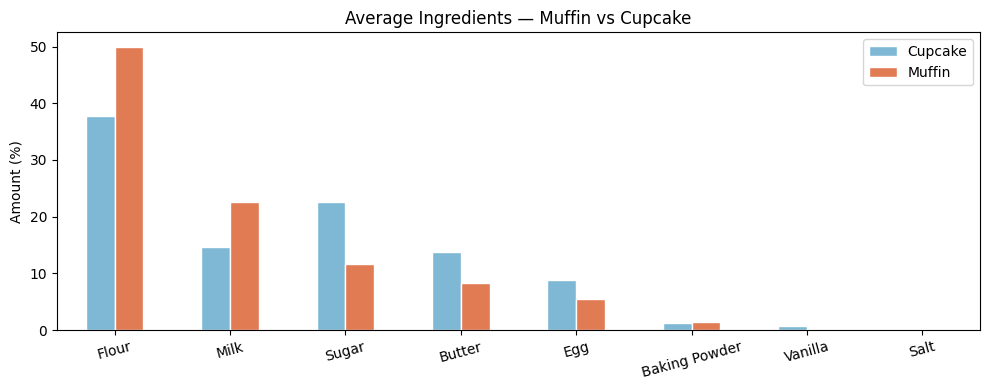

In [20]:
# Mean ingredient comparison
mean_df = df.groupby('Type').mean()
mean_df.T.plot(kind='bar', color=['#7EB8D4', '#E07B54'], figsize=(10, 4), edgecolor='white')
plt.title('Average Ingredients — Muffin vs Cupcake')
plt.ylabel('Amount (%)')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [21]:
# Features and target
X = df.drop('Type', axis=1)
y = df['Type']

# Encode target: Cupcake=0, Muffin=1
le = LabelEncoder()
y = le.fit_transform(y)
print('Classes:',le.classes_)  # index 0 and 1

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape[0])
print('Test  size:', X_test.shape[0])

# Scale features (important for SVM and KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Preprocessing done!')

Classes: ['Cupcake' 'Muffin']
Train size: 16
Test  size: 4
Preprocessing done!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129473 (\N{CUPCAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


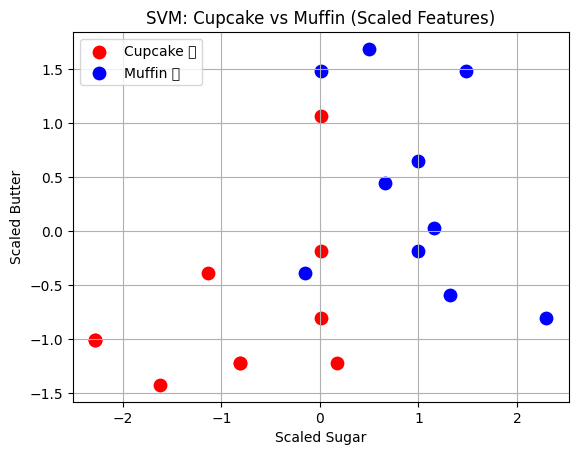

In [22]:
# Get column indices
sugar_col = X.columns.get_loc('Sugar')
butter_col = X.columns.get_loc('Butter')

# Scale features
X_scaled = scaler.transform(X)

# Split by class (VERY IMPORTANT for clarity)
cupcake = X_scaled[y == 1]
muffin = X_scaled[y == 0]

# Plot points
plt.scatter(cupcake[:, sugar_col], cupcake[:, butter_col],
            color='red', label='Cupcake 🧁', s=80)

plt.scatter(muffin[:, sugar_col], muffin[:, butter_col],
            color='blue', label='Muffin 🧁', s=80)

# Labels
plt.xlabel("Scaled Sugar")
plt.ylabel("Scaled Butter")
plt.title("SVM: Cupcake vs Muffin (Scaled Features)")
plt.grid(True)

# Legend (IMPORTANT)
plt.legend()

plt.show()

## 5. Model 01 — SVM (Support Vector Machine)

Accuracy: 0.75
Confusion Matrix:
 [[1 1]
 [0 2]]
Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



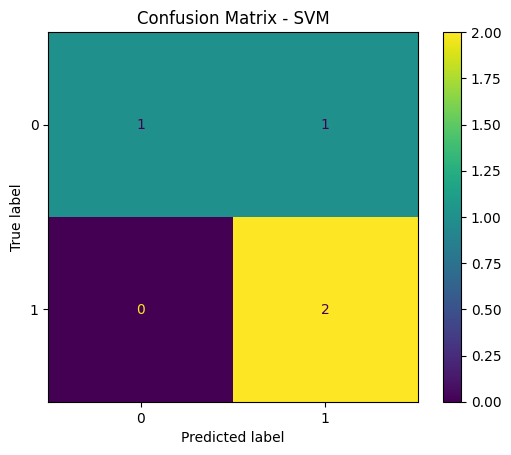

In [23]:
# Train
model = SVC(kernel='rbf', C=1, random_state=42) #kernal ='rbf' / 'linear' /'poly', degree =2,3,..
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

#Evaluation Metrics
cm = confusion_matrix(y_test, y_pred)
print("="*55)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("="*55)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("="*55)
print("Report:\n", classification_report(y_test, y_pred))
print("="*55)
# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

Model Predictions

In [28]:
# New recipe (example)
# Flour, Milk, Sugar, Butter, Egg, Baking Powder, Vanilla, Salt
new_data = [[56, 20, 20, 15,6 , 1, 1, 0]]

# Predict
scaler = StandardScaler()
new_data = scaler.fit_transform(new_data)
prediction = model.predict(new_data)

# Show result nicely
print("📊 Recipe Analysis Result")
if prediction[0] == 1:
    print("🧁 This recipe is predicted as: CUPCAKE")
else:
    print("🍪 This recipe is predicted as: MUFFIN")

📊 Recipe Analysis Result
🧁 This recipe is predicted as: CUPCAKE


## 6. Model 02 — KNN (K-Nearest Neighbors)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

print('KNN library imported!')

KNN library imported!


Accuracy: 0.75
Confusion Matrix:
 [[1 1]
 [0 2]]
Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



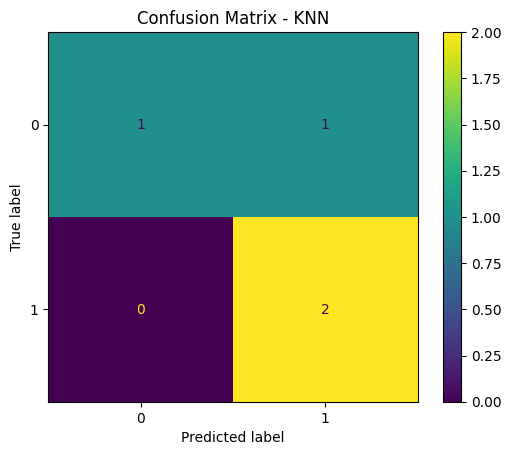

In [26]:
# Train
knn_model = KNeighborsClassifier(n_neighbors=3)  # n_neighbors = 3, 5, 7, ...
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Evaluation Metrics
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("="*55)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("="*55)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("="*55)
print("Report:\n", classification_report(y_test, y_pred_knn))
print("="*55)
# Confusion Matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

Model Predictions

In [29]:
# New recipe (example)
# Flour, Milk, Sugar, Butter, Egg, Baking Powder, Vanilla, Salt
new_data = [[100, 80, 40, 30, 10, 10, 1, 0]]

# Predict
scaler = StandardScaler()
new_data = scaler.fit_transform(new_data)
prediction_knn = knn_model.predict(new_data)

# Show result nicely
print("📊 Recipe Analysis Result")
if prediction_knn[0] == 1:
    print("🧁 This recipe is predicted as: CUPCAKE")
else:
    print("🍪 This recipe is predicted as: MUFFIN")

📊 Recipe Analysis Result
🧁 This recipe is predicted as: CUPCAKE
